# AI 이미지 검색 엔진 만들기
- 빠른 이미지 검색을 위한 Vector Database 실습

In [7]:
%pip install -q chromadb transformers

## 1.Dataset

- Food-11 데이터셋 중 evaluation 데이터 90장씩
- https://www.kaggle.com/datasets/trolukovich/food11-image-dataset

In [10]:
!unzip -q /content/sample_data/Food-11.zip

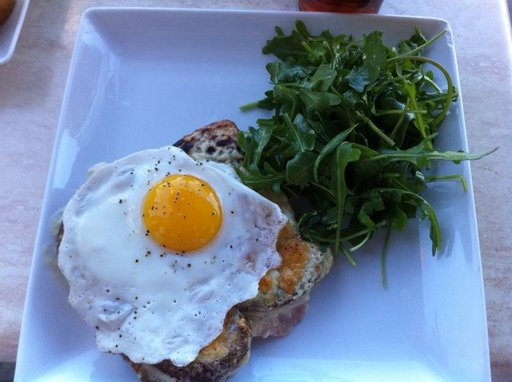

In [11]:
from PIL import Image

img = Image.open('test/Egg/10.jpg')

img

## 2.Image Vectorizer 모델 로드

https://huggingface.co/facebook/dino-vits16

In [12]:
# ViT(vision Transformer) 모델 : 'facebook/dino-vits16'
from transformers import ViTImageProcessor, ViTModel


# ViT(vision Transformer) 모델을 위한 feature_extractor를 불러옴
feature_extractor = ViTImageProcessor.from_pretrained('facebook/dino-vits16')

# ViT 모델을 불러와서 CUDA로 이동
model = ViTModel.from_pretrained('facebook/dino-vits16').to('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: facebook/dino-vits16
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

## 3.Embedding

In [14]:
# return_tensors="pt" 설정하여 PyTorch 텐서 형식으로 변환
img_tensor = feature_extractor(images=img, return_tensors="pt").to("cuda")

# 모델을 사용하여 이미지 특징 벡터 추출
outputs = model(**img_tensor)

# 최종 이미지 임베딩
embedding = outputs.pooler_output.detach().cpu().numpy().squeeze()


In [15]:
# 최종 이미지 임베딩 벡터 출력
embedding

array([ 9.63509977e-01,  2.10217059e-01, -4.04675990e-01,  9.75704432e-01,
        4.27440181e-03, -5.44133544e-01, -8.38486254e-01,  9.99904692e-01,
       -9.81910229e-01, -9.65570927e-01,  9.73589480e-01, -9.70870733e-01,
        9.52637315e-01,  5.55847049e-01,  5.54648161e-01,  9.50520098e-01,
        9.98388827e-01,  5.95965743e-01,  9.92728949e-01,  6.38022274e-02,
        5.96034765e-01, -9.89874065e-01, -5.71758687e-01, -9.95386899e-01,
       -2.43352190e-01, -4.21228021e-01,  8.85906637e-01, -9.81422186e-01,
        5.26730180e-01, -9.56862271e-01, -5.66594601e-01,  1.53112295e-03,
       -3.63898695e-01, -6.79273963e-01, -3.01589489e-01, -9.53664243e-01,
        9.91836965e-01,  9.78353858e-01, -8.93371463e-01,  2.13222221e-01,
        9.44808960e-01,  9.94461954e-01, -1.16959825e-01,  9.00942564e-01,
       -4.63724345e-01,  1.03648633e-01, -9.98846054e-01,  4.18986171e-01,
       -9.89978611e-01, -7.36302733e-01, -4.97000277e-01,  9.97310579e-01,
        9.39957500e-01,  

In [16]:
# ViT 모델의 pooler_output이 384차원의 벡터를 반환했다는 의미
# 이 벡터는 이미지의 특징(feature)를 압축한 값
# 유사도 검색, 이미지 분류, 군집화, 추천 시스템 등에 사용
embedding.shape

(384,)

## 4.Chroma DB
- Chroma(크로마)는 벡터 데이터베이스(Vector Database) 중 하나로, LLM(대형 언어 모델)과 검색 시스템을 위한 최적화된 데이터베이스이다.
- 벡터 데이터베이스는 문서, 이미지, 텍스트 등의 데이터를 숫자로 변환한 벡터 형식으로 저장하고 검색하는 데이터베이스이다.
- 기존의 관계형 데이터베이스(MySQL, PostgreSQL)와 달리 유사한 데이터를 빠르게 검색할 수 있는 기능을 제공한다.
- https://www.trychroma.com

In [17]:
import chromadb

# chromadb 클라이언트 객체 생성(메모리 기반 저장소를 사용) -> 컴퓨터가 꺼졌다 켜지면 데이터 사라짐.
client = chromadb.Client()

# 새로운 데이터 저장 공간 생성(sql에서 table과 비슷)
# 'food11'이라는 상자 이름(table)을 만들고, 앞으로 음식 관련 데이터를 이 컬렉션에 넣으면 됨.
collection = client.create_collection('food11')

## 5.모든 이미지 벡터화

In [18]:
from glob import glob

img_list = sorted(glob('test/*/*.jpg'))

len(img_list)

990

In [34]:
from tqdm import tqdm

embeddings = []     # 임베딩 벡터 저장
metadatas = []      # 메타 데이터 저장(이미지에 대한 추가 정보 저장, 경로나 클래스)
ids = []            # id 저장(각 이미지의 고유 ID 저장)

for i, img_path in enumerate(tqdm(img_list)):

    # 이미지 열기
    img = Image.open(img_path)

    # 클래스 정보 추출
    cls = img_path.split('/')[1]

    # 이미지 데이터를 ViT feature_extractor를 통해 텐서 변환
    img_tensor = feature_extractor(images=img, return_tensors="pt").to("cuda")
    outputs = model(**img_tensor)

    embedding = outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

    embeddings.append(embedding)

    metadatas.append({
        'uri': img_path,
        'name': cls})

    ids.append(str(i))

100%|██████████| 990/990 [00:17<00:00, 55.33it/s]


## 6.임베딩을 데이터베이스에 저장

In [35]:
collection.add(
    embeddings = embeddings,        # 벡터 데이터를 리스트 형태로 저장
    metadatas = metadatas,          # 저장하고 싶은 데이터를 묶어서 저장
    ids = ids                       # 각 데이터에 대한 고유 ip
)

## 7.Test1

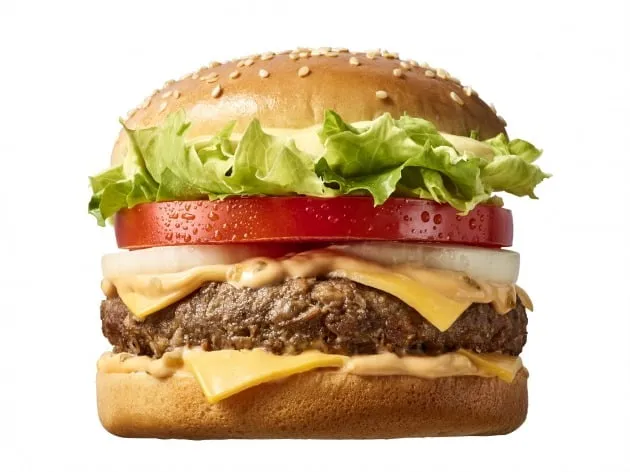

In [21]:
import requests

test_img = Image.open(requests.get("https://i.ibb.co/7Ksr5mw/yNp6qTS.png", stream=True).raw).convert("RGB")

test_img

In [22]:
test_img_tensor = feature_extractor(images=test_img, return_tensors="pt").to("cuda")
test_outputs = model(**test_img_tensor)

test_embedding = test_outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

len(test_embedding)

384

In [23]:
# 쿼리 날리는 거
query_results = collection.query(
    query_embeddings = [test_embedding],
    n_results = 3
)

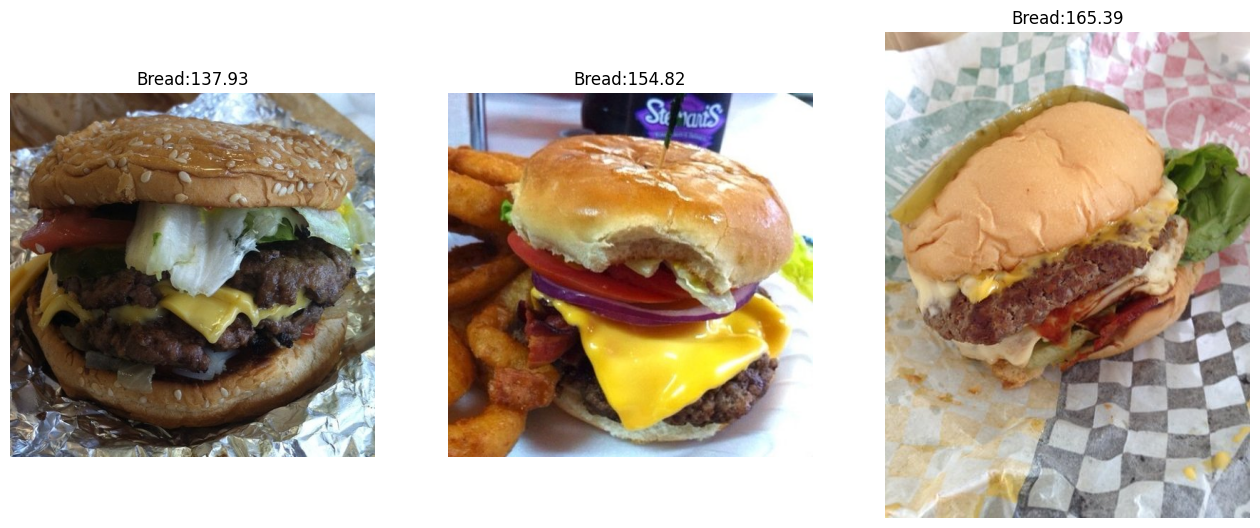

In [25]:
# 시각화
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1,3,figsize=(16,10))

for i, metadata in enumerate(query_results['metadatas'][0]):
    distance = query_results['distances'][0][i]

    # 이미지 불러오기 및 시각화
    axes[i].imshow(Image.open(metadata['uri']))
    axes[i].set_title(f"{metadata['name']}:{distance:.2f}")
    axes[i].axis('off')

## 8.테스트를 위한 함수화

In [26]:
def query(img_url, n_results=3):
    test_img = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

    test_img_tensor = feature_extractor(images=test_img, return_tensors="pt").to("cuda")
    test_outputs = model(**test_img_tensor)

    test_embedding = test_outputs.pooler_output.detach().cpu().numpy().squeeze().tolist()

    query_results = collection.query(
        query_embeddings = [test_embedding],
        n_results = n_results
        )

    fig, axes = plt.subplots(1,n_results+1,figsize=(16,10))

    axes[0].imshow(test_img)
    axes[0].set_title('Query')
    axes[0].axis('off')

    for i, metadata in enumerate(query_results['metadatas'][0]):
        distance = query_results['distances'][0][i]     # 해당 이미지의 유사도 거리

        # 이미지 불러오기 및 시각화
        axes[i+1].imshow(Image.open(metadata['uri']))
        axes[i+1].set_title(f"{metadata['name']}:{distance:.2f}")
        axes[i+1].axis('off')

    return query_results

{'ids': [['3', '52', '88']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'uri': 'test/Bread/11.jpg', 'name': 'Bread'},
   {'uri': 'test/Bread/56.jpg', 'name': 'Bread'},
   {'uri': 'test/Bread/89.jpg', 'name': 'Bread'}]],
 'distances': [[160.97413635253906, 194.1515655517578, 202.11737060546875]]}

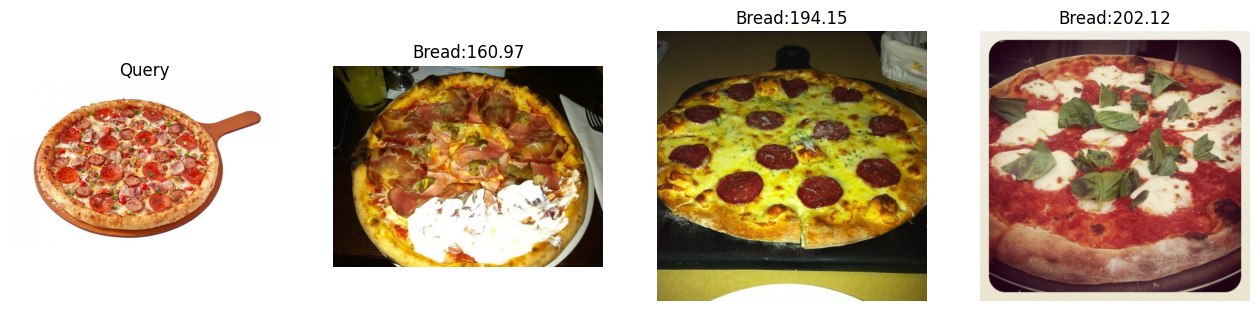

In [27]:
query("https://dimg.donga.com/wps/NEWS/IMAGE/2024/03/19/124032496.4.jpg")

## 9.Test2

{'ids': [['69', '635', '705']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'uri': 'test/Bread/71.jpg', 'name': 'Bread'},
   {'name': 'Rice', 'uri': 'test/Rice/13.jpg'},
   {'name': 'Rice', 'uri': 'test/Rice/77.jpg'}]],
 'distances': [[212.739501953125, 217.44338989257812, 220.25917053222656]]}

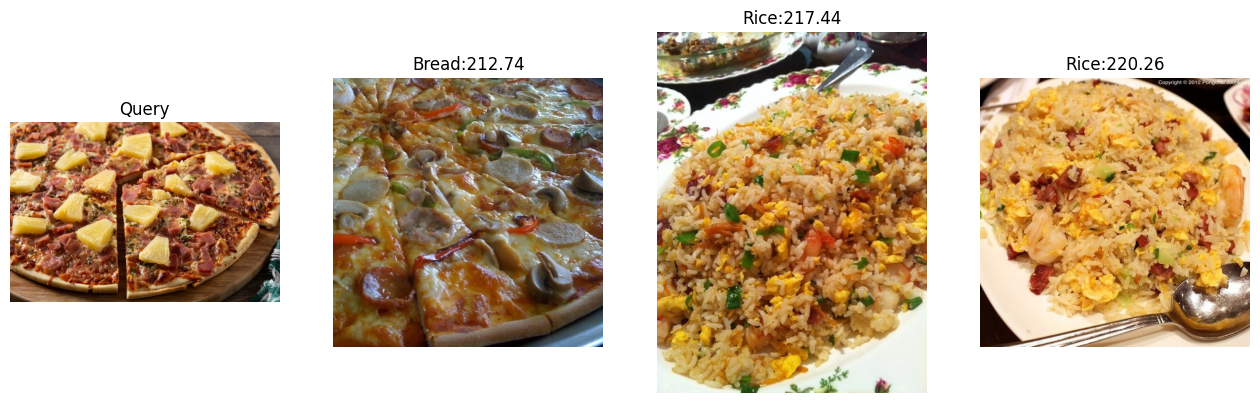

In [28]:
query('https://health.chosun.com/site/data/img_dir/2024/04/03/2024040302318_0.jpg')

{'ids': [['556', '835', '817']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'name': 'Noodles-Pasta', 'uri': 'test/Noodles-Pasta/23.jpg'},
   {'name': 'Soup', 'uri': 'test/Soup/31.jpg'},
   {'name': 'Soup', 'uri': 'test/Soup/15.jpg'}]],
 'distances': [[226.11776733398438, 234.59893798828125, 237.3148651123047]]}

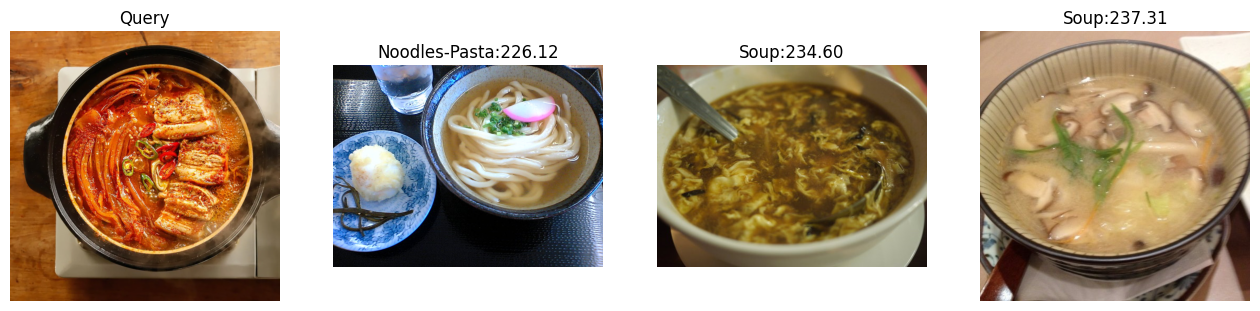

In [30]:
query('https://i.pinimg.com/originals/85/1b/12/851b12e450bc4151205fcb5465326688.png')

{'ids': [['303', '239', '322']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'uri': 'test/Egg/39.jpg', 'name': 'Egg'},
   {'uri': 'test/Dessert/62.jpg', 'name': 'Dessert'},
   {'name': 'Egg', 'uri': 'test/Egg/56.jpg'}]],
 'distances': [[210.99229431152344, 218.54080200195312, 219.1276092529297]]}

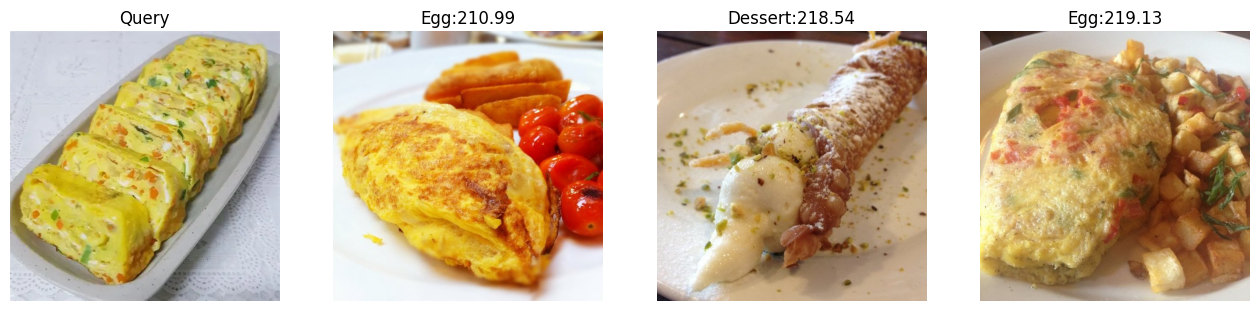

In [31]:
query('https://tse4.mm.bing.net/th/id/OIP.08YoHjXr8QzBsW8SVyyrFgHaHa?r=0&cb=thfc1falcon2&rs=1&pid=ImgDetMain&o=7&rm=3')

### Top-K 검색 예시 (K=5)

{'ids': [['69', '635', '705', '68', '3']],
 'embeddings': None,
 'documents': [[None, None, None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'name': 'Bread', 'uri': 'test/Bread/71.jpg'},
   {'uri': 'test/Rice/13.jpg', 'name': 'Rice'},
   {'uri': 'test/Rice/77.jpg', 'name': 'Rice'},
   {'uri': 'test/Bread/70.jpg', 'name': 'Bread'},
   {'name': 'Bread', 'uri': 'test/Bread/11.jpg'}]],
 'distances': [[212.739501953125,
   217.44338989257812,
   220.25917053222656,
   228.47698974609375,
   232.4009246826172]]}

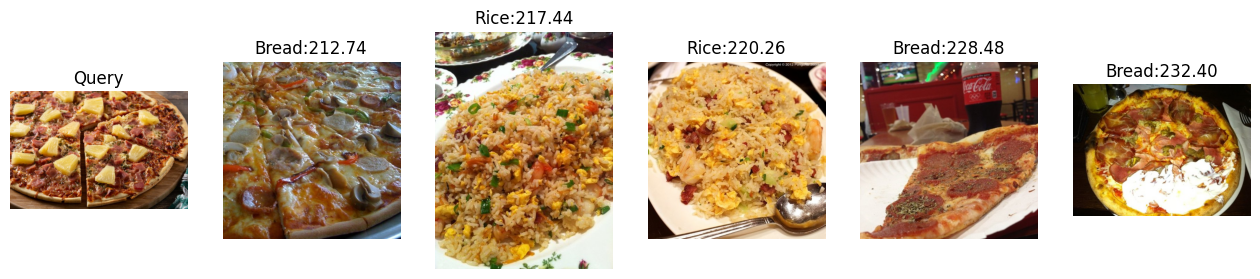

In [33]:
query('https://health.chosun.com/site/data/img_dir/2024/04/03/2024040302318_0.jpg', n_results=5)

{'ids': [['683', '662', '703']],
 'embeddings': None,
 'documents': [[None, None, None]],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'uri': 'test/Rice/57.jpg', 'name': 'Rice'},
   {'name': 'Rice', 'uri': 'test/Rice/38.jpg'},
   {'name': 'Rice', 'uri': 'test/Rice/75.jpg'}]],
 'distances': [[180.986572265625, 181.47320556640625, 188.13490295410156]]}

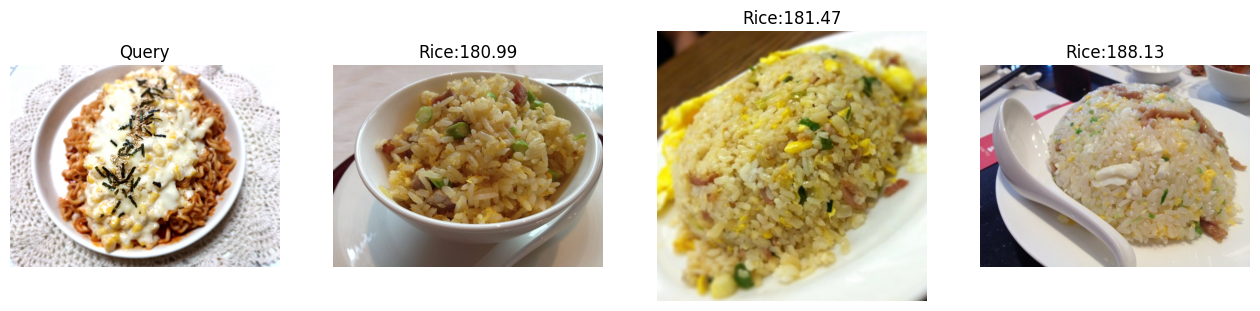

In [32]:
query('https://recipe1.ezmember.co.kr/cache/recipe/2023/04/12/b661e553742c9f1549108cf9a8ae55241.jpg')